<a href="https://colab.research.google.com/github/gnganesh99/NN_Error/blob/ayush_dev/notebooks/STM/stm_multiscale_train_size_variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Get data

In [4]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [5]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "L1" # "L1", "L2", or "cos"
append_image_type = 'pad' #pad, interpolate
model_type = 'im2spec'

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


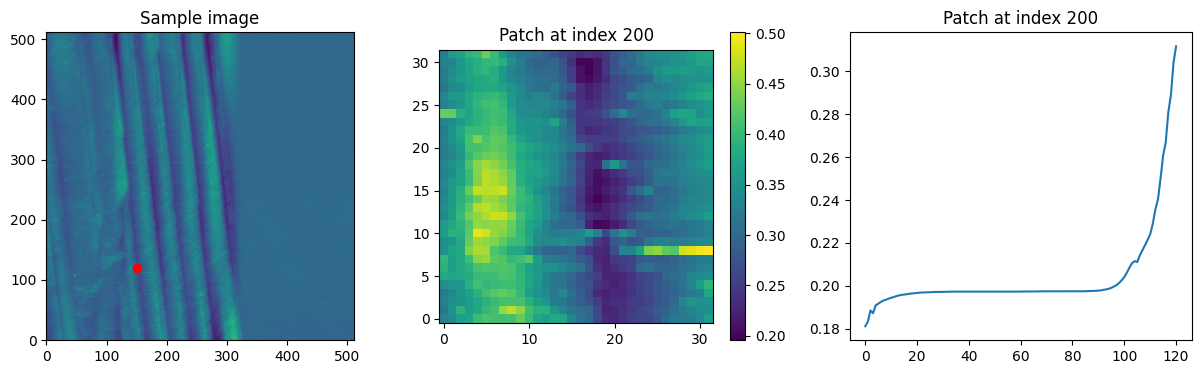

In [6]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [7]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

# Variance with train size

In [8]:
def split_augment(train_size, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images_all, spectra_all, swap_coordinates_all, train_size = train_size, random_state=42)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug


Testing with test size: 0.1
Augmented images shape: (816, 32, 32), Augmented spectra shape: (816, 121), Augmented coordinates shape: (816, 3)
Augmented images shape: (7376, 32, 32), Augmented spectra shape: (7376, 121), Augmented coordinates shape: (7376, 3)


 91%|█████████ | 91/100 [01:39<00:09,  1.06s/it, train_loss=0.0014, val_loss=0.0015]

SWA triggered at epoch 90


100%|██████████| 100/100 [01:48<00:00,  1.09s/it, train_loss=0.0014, val_loss=0.0015]


  Error targets train shape: (816, 1)
  Error targets test shape: (7376, 1)


 92%|█████████▏| 92/100 [00:15<00:01,  6.09it/s, train_loss=0.0001, val_loss=0.0000]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:16<00:00,  6.06it/s, train_loss=0.0001, val_loss=0.0000]
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.

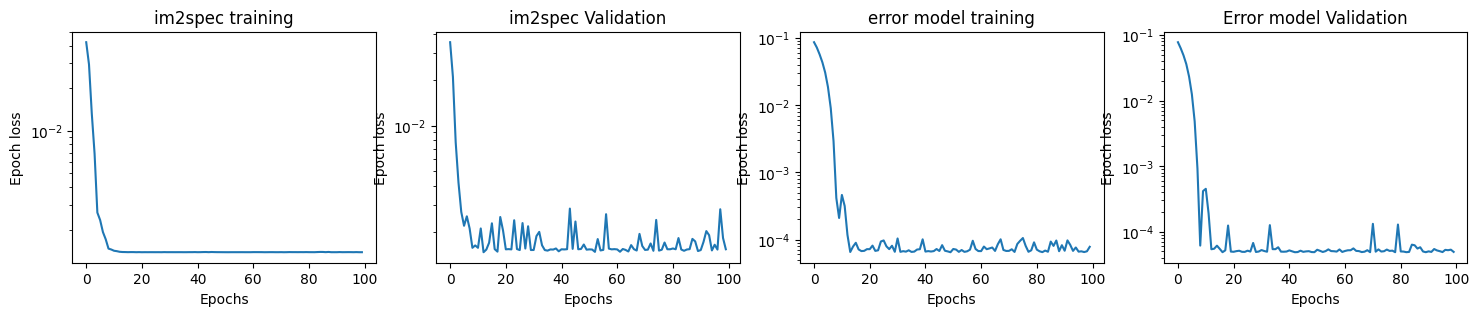


Testing with test size: 0.2
Augmented images shape: (1632, 32, 32), Augmented spectra shape: (1632, 121), Augmented coordinates shape: (1632, 3)
Augmented images shape: (6560, 32, 32), Augmented spectra shape: (6560, 121), Augmented coordinates shape: (6560, 3)


 91%|█████████ | 91/100 [01:51<00:10,  1.22s/it, train_loss=0.0015, val_loss=0.0015]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:02<00:00,  1.22s/it, train_loss=0.0015, val_loss=0.0016]


  Error targets train shape: (1632, 1)
  Error targets test shape: (6560, 1)


 91%|█████████ | 91/100 [00:31<00:03,  2.93it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:34<00:00,  2.92it/s, train_loss=0.0001, val_loss=0.0001]


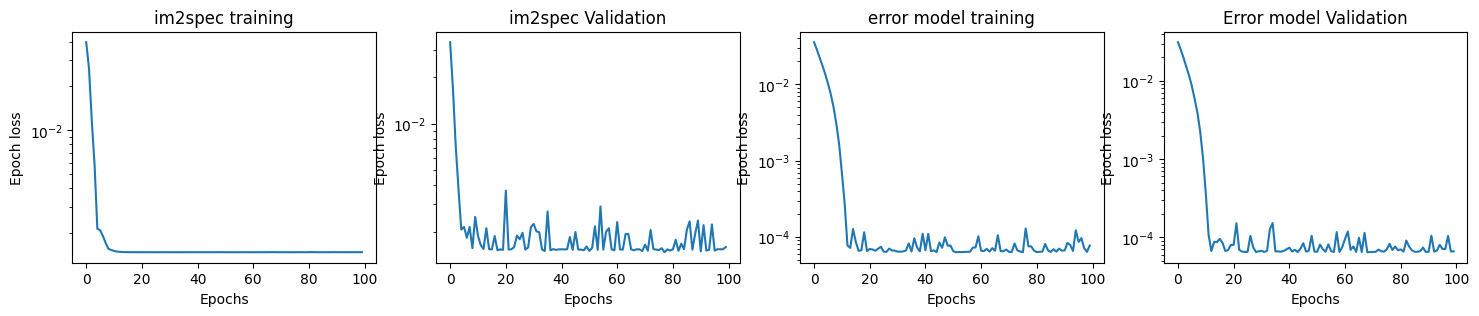


Testing with test size: 0.30000000000000004
Augmented images shape: (2456, 32, 32), Augmented spectra shape: (2456, 121), Augmented coordinates shape: (2456, 3)
Augmented images shape: (5736, 32, 32), Augmented spectra shape: (5736, 121), Augmented coordinates shape: (5736, 3)


 91%|█████████ | 91/100 [02:10<00:12,  1.43s/it, train_loss=0.0018, val_loss=0.0017]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:23<00:00,  1.43s/it, train_loss=0.0016, val_loss=0.0016]


  Error targets train shape: (2456, 1)
  Error targets test shape: (5736, 1)


 91%|█████████ | 91/100 [00:52<00:05,  1.73it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:58<00:00,  1.72it/s, train_loss=0.0001, val_loss=0.0001]


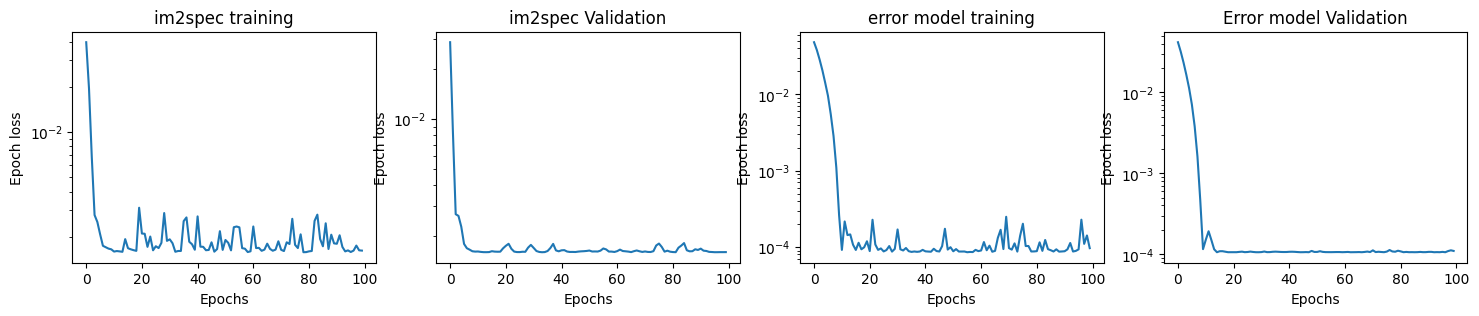


Testing with test size: 0.4
Augmented images shape: (3272, 32, 32), Augmented spectra shape: (3272, 121), Augmented coordinates shape: (3272, 3)
Augmented images shape: (4920, 32, 32), Augmented spectra shape: (4920, 121), Augmented coordinates shape: (4920, 3)


 91%|█████████ | 91/100 [02:23<00:14,  1.57s/it, train_loss=0.0020, val_loss=0.0015]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:37<00:00,  1.57s/it, train_loss=0.0017, val_loss=0.0015]


  Error targets train shape: (3272, 1)
  Error targets test shape: (4920, 1)


 91%|█████████ | 91/100 [01:12<00:07,  1.23it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [01:20<00:00,  1.25it/s, train_loss=0.0001, val_loss=0.0001]


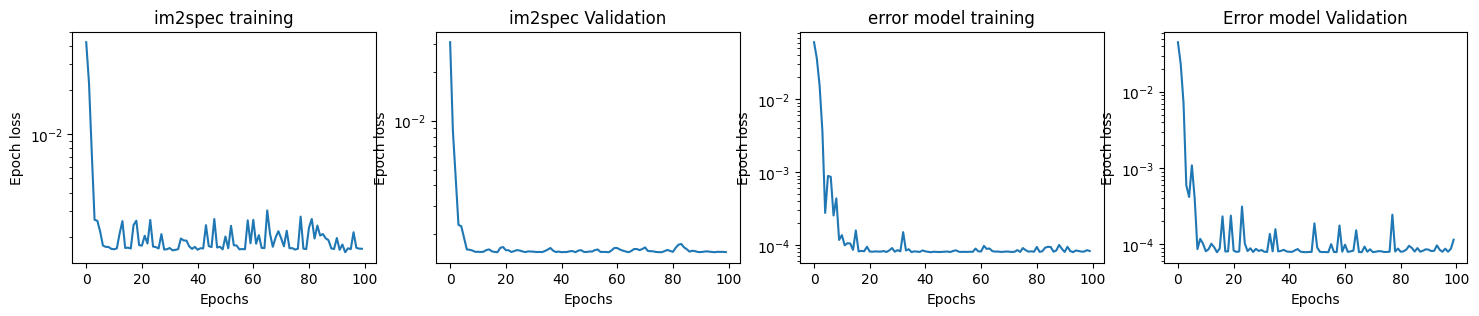


Testing with test size: 0.5
Augmented images shape: (4096, 32, 32), Augmented spectra shape: (4096, 121), Augmented coordinates shape: (4096, 3)
Augmented images shape: (4096, 32, 32), Augmented spectra shape: (4096, 121), Augmented coordinates shape: (4096, 3)


 91%|█████████ | 91/100 [02:35<00:15,  1.70s/it, train_loss=0.0016, val_loss=0.0015]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:50<00:00,  1.71s/it, train_loss=0.0016, val_loss=0.0016]


  Error targets train shape: (4096, 1)
  Error targets test shape: (4096, 1)


 91%|█████████ | 91/100 [01:30<00:08,  1.01it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [01:38<00:00,  1.01it/s, train_loss=0.0001, val_loss=0.0001]


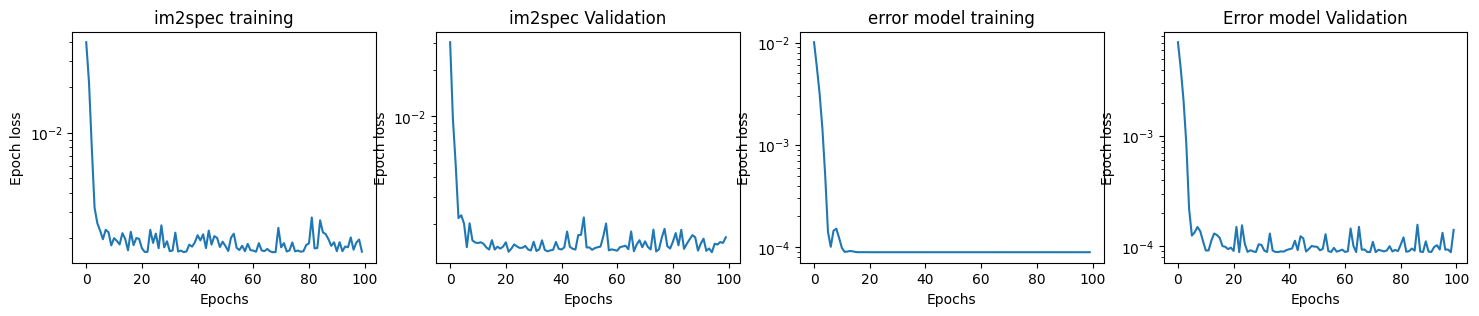


Testing with test size: 0.6
Augmented images shape: (4912, 32, 32), Augmented spectra shape: (4912, 121), Augmented coordinates shape: (4912, 3)
Augmented images shape: (3280, 32, 32), Augmented spectra shape: (3280, 121), Augmented coordinates shape: (3280, 3)


 91%|█████████ | 91/100 [02:46<00:16,  1.83s/it, train_loss=0.0020, val_loss=0.0014]

SWA triggered at epoch 90


100%|██████████| 100/100 [03:03<00:00,  1.83s/it, train_loss=0.0016, val_loss=0.0013]


  Error targets train shape: (4912, 1)
  Error targets test shape: (3280, 1)


 91%|█████████ | 91/100 [01:49<00:10,  1.20s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:00<00:00,  1.21s/it, train_loss=0.0001, val_loss=0.0001]


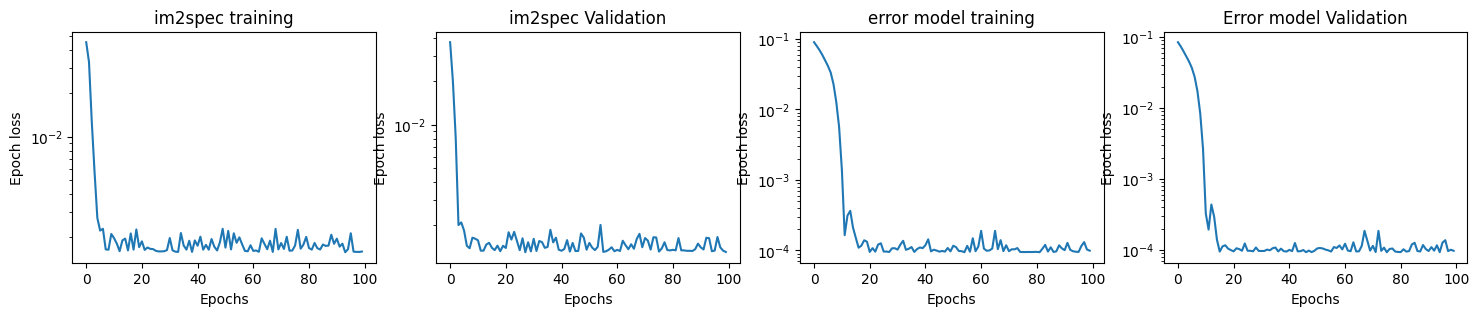


Testing with test size: 0.7000000000000001
Augmented images shape: (5728, 32, 32), Augmented spectra shape: (5728, 121), Augmented coordinates shape: (5728, 3)
Augmented images shape: (2464, 32, 32), Augmented spectra shape: (2464, 121), Augmented coordinates shape: (2464, 3)


 91%|█████████ | 91/100 [02:58<00:17,  1.97s/it, train_loss=0.0016, val_loss=0.0014]

SWA triggered at epoch 90


100%|██████████| 100/100 [03:16<00:00,  1.96s/it, train_loss=0.0018, val_loss=0.0018]


  Error targets train shape: (5728, 1)
  Error targets test shape: (2464, 1)


 91%|█████████ | 91/100 [02:08<00:12,  1.41s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:21<00:00,  1.41s/it, train_loss=0.0001, val_loss=0.0001]


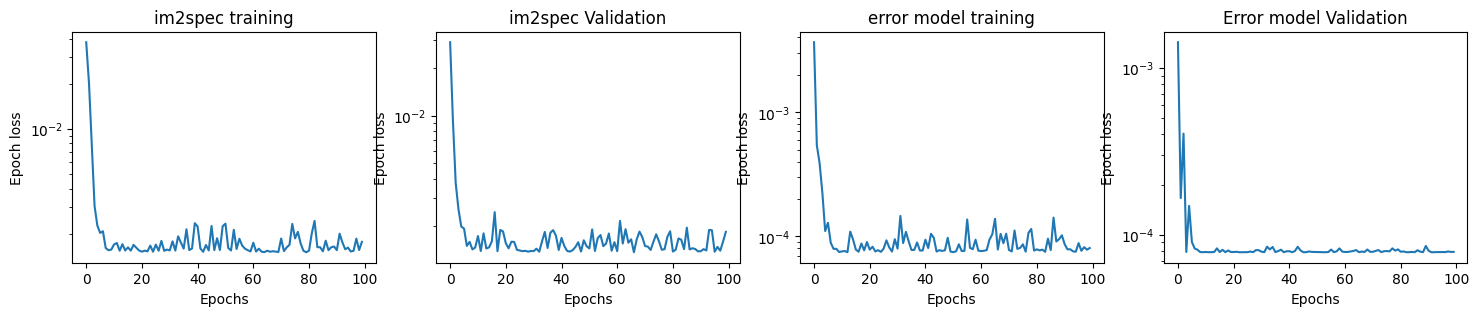


Testing with test size: 0.8
Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)


 91%|█████████ | 91/100 [03:05<00:18,  2.04s/it, train_loss=0.0017, val_loss=0.0013]

SWA triggered at epoch 90


100%|██████████| 100/100 [03:24<00:00,  2.04s/it, train_loss=0.0017, val_loss=0.0015]


  Error targets train shape: (6552, 1)
  Error targets test shape: (1640, 1)


 91%|█████████ | 91/100 [02:27<00:14,  1.62s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [02:42<00:00,  1.63s/it, train_loss=0.0001, val_loss=0.0001]


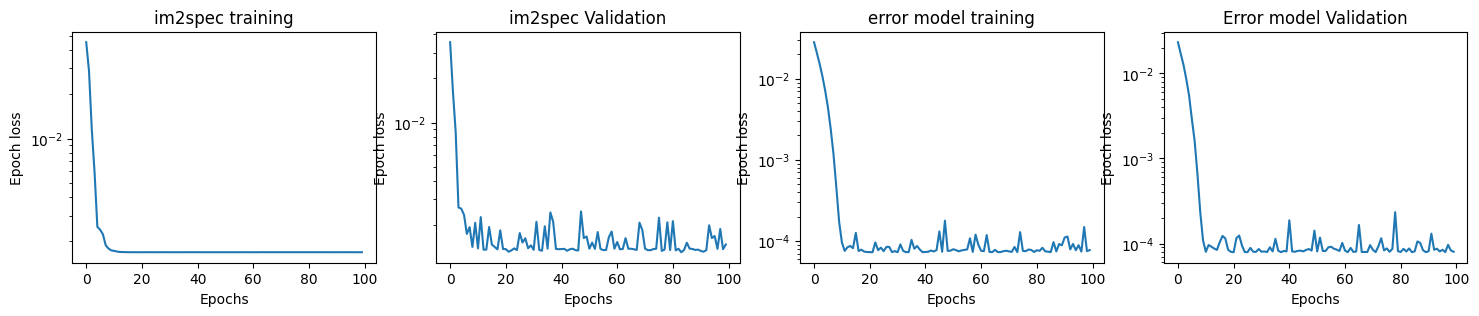


Testing with test size: 0.9
Augmented images shape: (7368, 32, 32), Augmented spectra shape: (7368, 121), Augmented coordinates shape: (7368, 3)
Augmented images shape: (824, 32, 32), Augmented spectra shape: (824, 121), Augmented coordinates shape: (824, 3)


 91%|█████████ | 91/100 [03:16<00:19,  2.19s/it, train_loss=0.0017, val_loss=0.0012]

SWA triggered at epoch 90


100%|██████████| 100/100 [03:35<00:00,  2.15s/it, train_loss=0.0017, val_loss=0.0012]


  Error targets train shape: (7368, 1)
  Error targets test shape: (824, 1)


 91%|█████████ | 91/100 [02:47<00:16,  1.83s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [03:03<00:00,  1.84s/it, train_loss=0.0001, val_loss=0.0001]


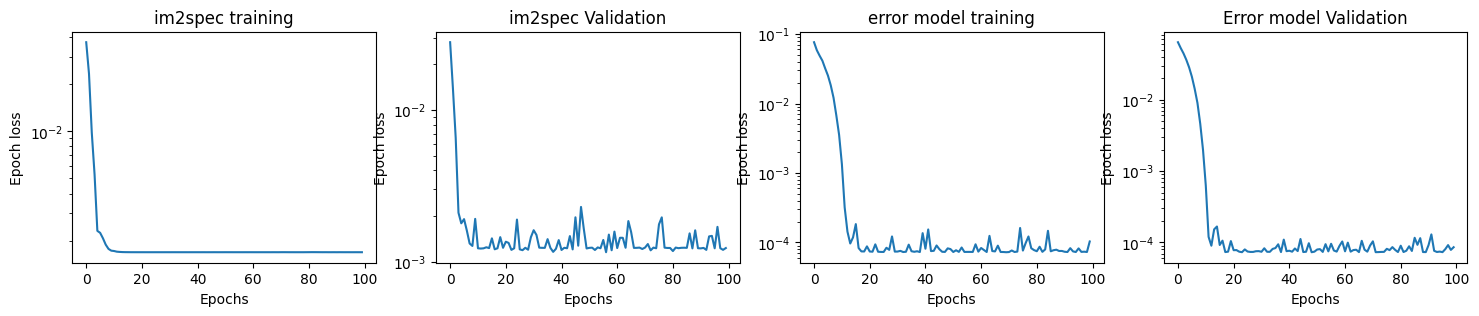

In [11]:
from sklearn.model_selection import train_test_split
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()
train_sizes = np.arange(0.1, 1, 0.1)

im2spec_train_losses = []
im2spec_val_losses = []
im2spec_test_losses = []

error_train_losses = []
error_val_losses = []
error_test_losses = []

for ts in train_sizes:



    print(f"\nTesting with test size: {ts}")

    #original_images, original_spectra, original_coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, coordinate_step = 15, image_norm=False, spectra_norm = False)
    images_train_ts, images_test_ts, spectra_train_ts, spectra_test_ts = split_augment(ts)


    if images_train_ts.shape[0] == 0 or images_test_ts.shape[0] == 0:
        print(f"Skipping test size {ts} due to insufficient training data.")
        continue

    # Train im2spec model on this train/test split
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imspec_model_ts = FNO_im2spec(
        target_size=out_dim,
        latent_dim=3,
        hidden_channels=32,
        n_modes=(16, 16),
        n_layers=4,
    ).to(device)

    #imspec_model_ts = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

    impsec_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(spectra_train_ts, dtype=torch.float32),
    )
    impsec_val_dataset_ts = TensorDataset(
        torch.tensor(images_test_ts, dtype=torch.float32),
        torch.tensor(spectra_test_ts, dtype=torch.float32),
    )

    im2spec_model_ts, im2spec_train_loss_ts, im2spec_val_loss_ts = train_model(
        imspec_model_ts,
        impsec_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train= False,
        val_dataset = impsec_val_dataset_ts,
        use_swa = True,
        last_swa_epochs = 0.1
    )


    im2spec_train_losses.append(im2spec_train_loss_ts)
    im2spec_val_losses.append(im2spec_val_loss_ts)

    imspec_model_ts.eval()
    with torch.no_grad():
        x_test_ts = torch.tensor(images_test_ts, dtype=torch.float32, device=device)
        y_test_ts = torch.tensor(spectra_test_ts, dtype=torch.float32, device=device)
        test_pred_ts = imspec_model_ts.predict(x_test_ts)
        im2spec_test_loss_ts = torch.nn.functional.mse_loss(test_pred_ts, y_test_ts).item()
    im2spec_test_losses.append(im2spec_test_loss_ts)

    # Train error model
    error_mean_ts, _, _ = err_estimation(imspec_model_ts, images_train_ts, spectra_train_ts, error_type=error_type)
    error_targets_ts = error_mean_ts.astype(np.float32).reshape(-1, 1)

    # Add error estimation for the test set
    error_mean_test_ts, _, _ = err_estimation(imspec_model_ts, images_test_ts, spectra_test_ts, error_type=error_type)
    error_targets_test_ts = error_mean_test_ts.astype(np.float32).reshape(-1, 1)

    print(f"  Error targets train shape: {error_targets_ts.shape}")
    print(f"  Error targets test shape: {error_targets_test_ts.shape}")

    latent_dim_ts = imspec_model_ts.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model_ts = CustomDecoder(encoder=imspec_model_ts.encoder, embed_dim=latent_dim_ts, target_size=1).to(device)

    error_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(error_targets_ts, dtype=torch.float32),
    )

    error_model_ts, error_train_loss_ts, error_val_loss_ts = train_model(
        error_model_ts,
        error_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        use_swa = True,
        last_swa_epochs = 0.1
    )

    plot_training_loss([im2spec_train_loss_ts], [im2spec_val_loss_ts], error_train_loss_ts, error_val_loss_ts)

    # Append all losses to the lists for box plotting
    error_train_losses.append(error_train_loss_ts)
    error_test_losses.append(error_mean_test_ts)
    error_val_losses.append(error_val_loss_ts)

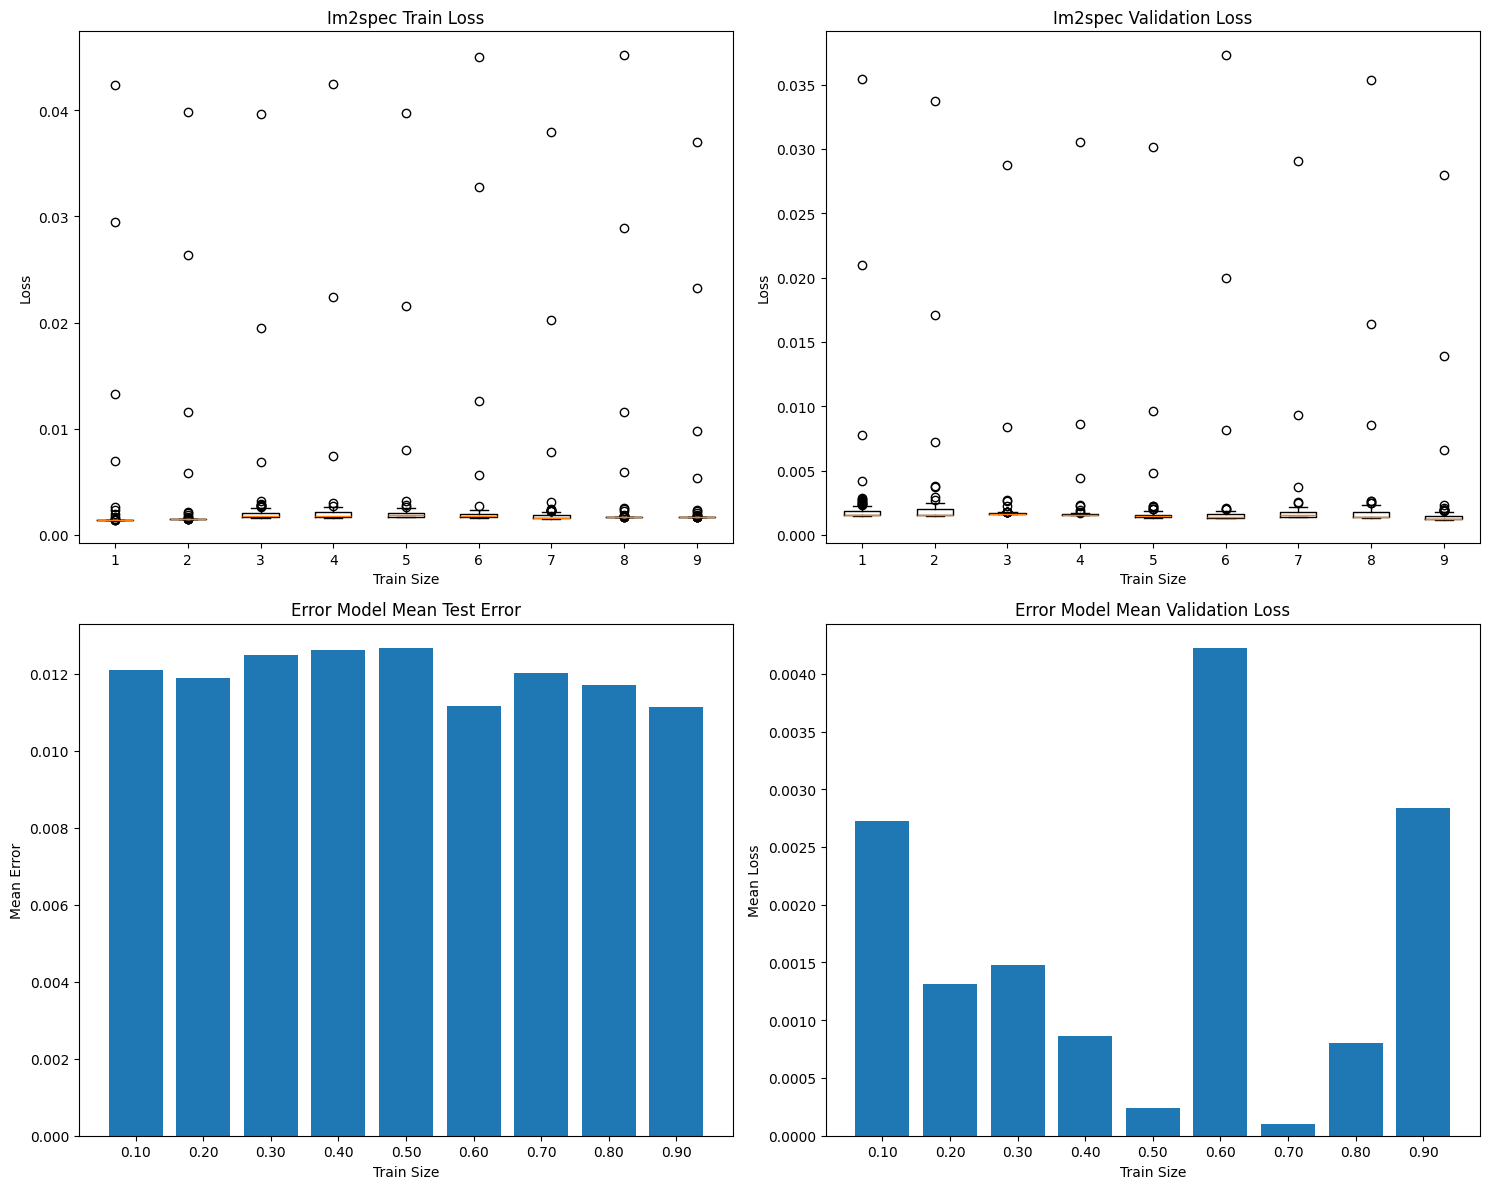

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean validation loss for the error model for bar plotting
mean_error_val_losses = [np.mean(losses) for losses in error_val_losses]

# Calculate mean of error_test_losses for bar plotting
mean_error_test_losses_per_train_size = [np.mean(err_arr) for err_arr in error_test_losses]

# Plot charts on a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Im2spec Train Loss Box Plot
axes[0, 0].boxplot(im2spec_train_losses)
axes[0, 0].set_title("Im2spec Train Loss")
axes[0, 0].set_xlabel("Train Size")
axes[0, 0].set_ylabel("Loss")

# Im2spec Validation Loss Box Plot
axes[0, 1].boxplot(im2spec_val_losses)
axes[0, 1].set_title("Im2spec Validation Loss")
axes[0, 1].set_xlabel("Train Size")
axes[0, 1].set_ylabel("Loss")

# Error Model Mean Test Error Bar Chart
axes[1, 0].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_test_losses_per_train_size)
axes[1, 0].set_title("Error Model Mean Test Error")
axes[1, 0].set_xlabel("Train Size")
axes[1, 0].set_ylabel("Mean Error")

# Error Model Mean Validation Loss Bar Chart
axes[1, 1].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_val_losses)
axes[1, 1].set_title("Error Model Mean Validation Loss")
axes[1, 1].set_xlabel("Train Size")
axes[1, 1].set_ylabel("Mean Loss")

plt.tight_layout()
plt.show()